In [15]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import os
from openai import OpenAI


In [16]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [17]:
class State(TypedDict):
    product_name: str
    basic_description: str
    features_benefits: str
    marketing_message: str
    final_description: str
    image_url: str


In [18]:
def generate_basic_description(state: State) -> State:
    product_name = state['product_name']
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that generates product descriptions."},
            {"role": "user", "content": f"Generate a basic description for the product: {product_name}."}
        ]
    )
    basic_description = response.choices[0].message.content.strip()

    return {"basic_description":basic_description}   ## whatever key defined in STate same key you have keep in return


In [19]:
def generate_feature_benefits(state: State) -> State:
    product_name = state['product_name']
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that generates features and benefits for a product."},
            {"role": "user", "content": f"Generate features and benefits for the product: {product_name}."}
        ]
    )
    features_benefits = response.choices[0].message.content.strip()

    return {"features_benefits":features_benefits}   ## whatever key defined in STate same key you have keep in return


In [20]:
def create_marketing_message(state: State) -> State:
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that creates marketing messages for products."},
            {"role": "user", "content": f"Create a marketing message based on the features and benefits: {state['features_benefits']}."}
        ]
    )
    
    marketing_message = response.choices[0].message.content.strip()
    return {"marketing_message": marketing_message}

In [21]:
def polish_final_description(state: State) -> State:
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that polishes product descriptions."},
            {"role": "user", "content": f"Polish the following product description and marketing message into a final description:\nBasic Description: {state['basic_description']}\nMarketing Message: {state['marketing_message']}"}
        ]
    )
    final_description = response.choices[0].message.content.strip()
    return {"final_description": final_description}

In [22]:
from pathlib import Path
import base64
def create_image(state: State) -> State:
    prompt = (
        f"Professional product photo of {state['product_name']}. "
        f"Clean background, marketing style. "
        f"Features: {state['features_benefits'][:500]}"
    )


    # DALL·E 3 was retired in May 2026. GPT Image returns base64, not a hosted URL.
    response = client.images.generate(
        model="gpt-image-2",
        prompt=prompt,
        size="1024x1024",
        n=1,
    )
    
    image_b64 = response.data[0].b64_json
    images_dir = Path("images")
    images_dir.mkdir(exist_ok=True)

    image_path = images_dir / f"{state['product_name'].lower().replace(' ', '_')}.png"
    image_path.write_bytes(base64.b64decode(image_b64))

    image_url = f"data:image/png;base64,{image_b64}"
    return {"image_url": image_url}

In [23]:
def build_workflow():
    """
    Build the workflow for the product description generation.
    """
    workflow = StateGraph(State)
    workflow.add_node("generate_basic_description", generate_basic_description)
    workflow.add_node("generate_feature_benefits", generate_feature_benefits)
    workflow.add_node("create_marketing_message", create_marketing_message)
    workflow.add_node("create_image", create_image)
    workflow.add_node("polish_final_description", polish_final_description)

    workflow.add_edge(START, "generate_basic_description")
    workflow.add_edge("generate_basic_description", "generate_feature_benefits")
    workflow.add_edge("generate_feature_benefits", "create_marketing_message")
    workflow.add_edge("create_marketing_message", "polish_final_description")
    workflow.add_edge("polish_final_description", "create_image")
    workflow.add_edge("create_image", END)

    chain = workflow.compile()
    return chain

        

In [24]:
chain = build_workflow()

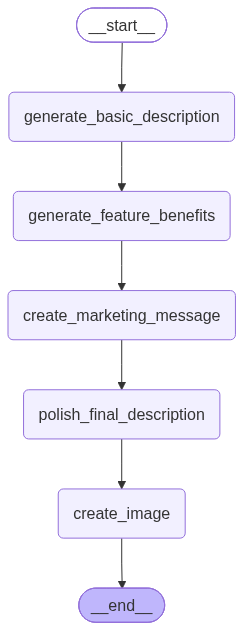

In [25]:

from IPython.display import Image, display

try:
    display(Image(chain.get_graph().draw_mermaid_png()))
except Exception as e:

    print(e)

In [26]:
product_name="Apple Pencil"
state = State(product_name=product_name, basic_description="", features_benefits="", marketing_message="", final_description="")
result = chain.invoke(state)


{'product_name': 'Apple Pencil',
 'basic_description': "The Apple Pencil is a cutting-edge stylus designed for use with compatible Apple devices, including iPads and iPad Pros. With its precise responsiveness and seamless integration with Apple's devices, the Apple Pencil offers a natural drawing and writing experience. Whether you're sketching, taking notes, or annotating documents, the Apple Pencil's advanced technology makes it a versatile tool for creativity and productivity.",
 'features_benefits': 'Features:\n\n1. Precision and accuracy: The Apple Pencil offers unparalleled precision and accuracy when drawing, sketching, or annotating on an iPad.\n\n2. Pressure sensitivity: With its advanced technology, the Apple Pencil can detect varying levels of pressure, allowing for dynamic line thickness and shading.\n\n3. Tilt and angle detection: The Apple Pencil can recognize the tilt and angle at which you hold it, enabling you to create realistic and nuanced strokes.\n\n4. Seamless int
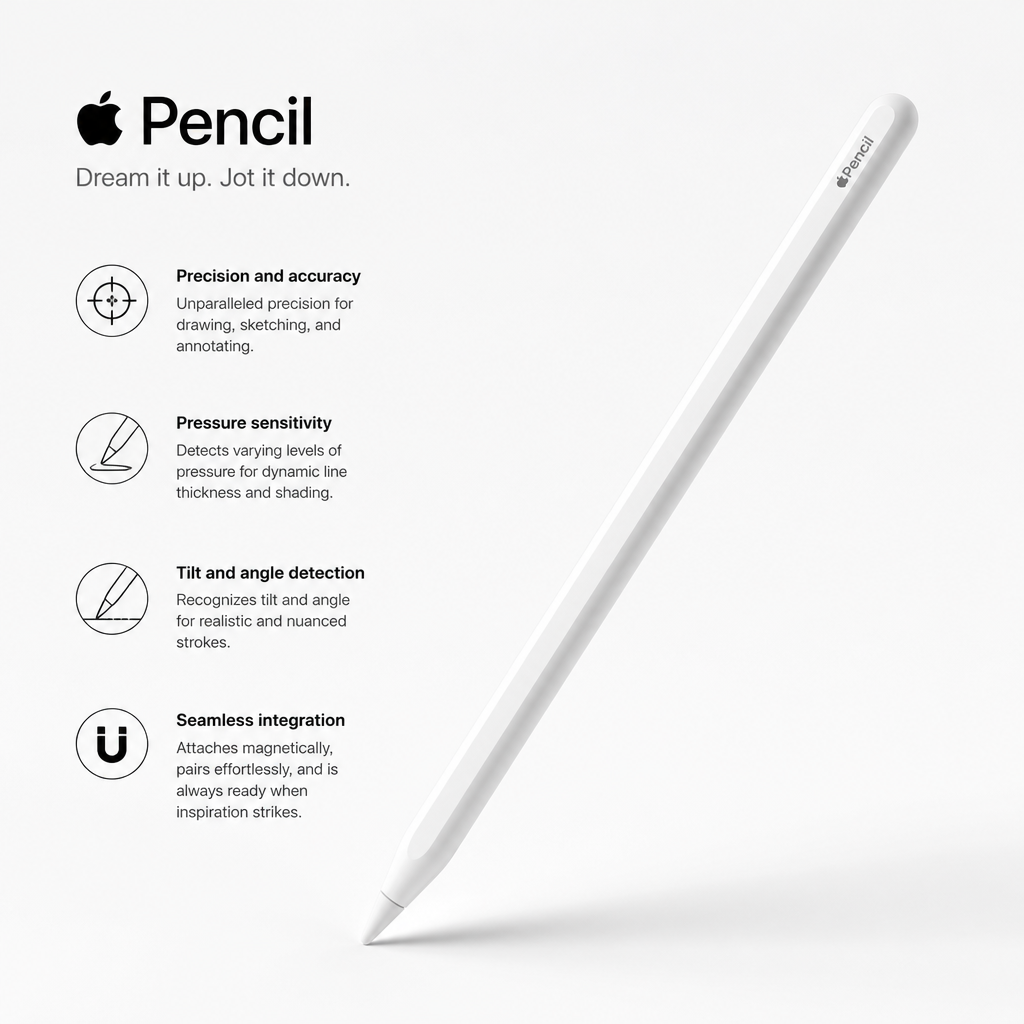

In [28]:
result